In [1]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import HumanMessage
from langchain_gigachat import GigaChat

In [2]:
import os
api_key = os.getenv("GIGA_API_KEY")

In [3]:
llm = llm_01 = GigaChat(
    credentials = api_key,
    verify_ssl_certs=False,
    scope = 'GIGACHAT_API_CORP',
    temperature=0.1,
    profanity_check = False,
    model="GigaChat",
)

=============================================================================================================

# State Reducers (Редьюсеры состояния)

## Обзор (Review)

Мы рассмотрели несколько способов определения схемы состояния в LangGraph, включая `TypedDict`, `Pydantic` и `Dataclasses`.

## Цели (Goals)

Теперь мы погрузимся в редьюсеры, которые определяют, как выполняются обновления состояния для конкретных ключей / каналов в схеме состояния.

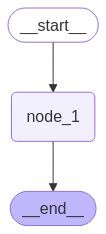

In [4]:
from typing_extensions import TypedDict
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

class State(TypedDict):
    foo: int

def node_1(state):
    print("---Node 1---")
    return {"foo": state['foo'] + 1}

# Build graph
builder = StateGraph(State)
builder.add_node("node_1", node_1)

# Logic
builder.add_edge(START, "node_1")
builder.add_edge("node_1", END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [5]:
graph.invoke({"foo" : 1})

---Node 1---


{'foo': 2}

Давай посмотрим на обновление состояния, return {"foo": state['foo'] + 1}.

Как обсуждалось ранее, по умолчанию LangGraph не знает предпочтительного способа обновления состояния.

Поэтому он просто перезапишет значение foo в node_1

```
return {"foo": state['foo'] + 1}
```


Если мы передадим {'foo': 1} на вход, состояние, возвращаемое графом, будет {'foo': 2}.


## Branching
Теперь рассмотрим случай, где наши узлы ветвятся.

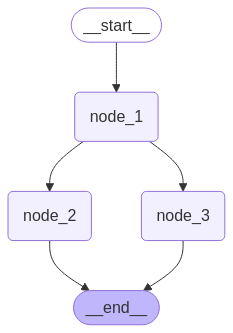

In [6]:
class State(TypedDict):
    foo: int

def node_1(state):
    print("---Node 1---")
    return {"foo": state['foo'] + 1}

def node_2(state):
    print("---Node 2---")
    return {"foo": state['foo'] + 1}

def node_3(state):
    print("---Node 3---")
    return {"foo": state['foo'] + 1}

# Build graph
builder = StateGraph(State)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# Logic
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_1", "node_3")
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [7]:
from langgraph.errors import InvalidUpdateError
try:
    graph.invoke({"foo" : 1})
except InvalidUpdateError as e:
    print(f"InvalidUpdateError occurred: {e}")


---Node 1---
---Node 2---
---Node 3---
InvalidUpdateError occurred: At key 'foo': Can receive only one value per step. Use an Annotated key to handle multiple values.
For troubleshooting, visit: https://python.langchain.com/docs/troubleshooting/errors/INVALID_CONCURRENT_GRAPH_UPDATE


**Мы** видим проблему! 

Узел 1 (Node 1) ветвится на узлы 2 и 3 (Nodes 2 and 3).

Узлы 2 и 3 выполняются параллельно, что означает, что они выполняются в одном и том же шаге графа (graph).

Оба узла пытаются перезаписать состояние (state) *в рамках одного шага*. 

Это создает неоднозначность для графа! Какое состояние (state) следует сохранить?
_____________________________________________________________

## Редукторы (Reducers)

[Редукторы](https://langchain-ai.github.io/langgraph/concepts/low_level/#reducers) дают нам общий способ решения этой проблемы.

Они указывают, как выполнять обновления.

Мы можем использовать тип `Annotated`, чтобы указать функцию-редуктор.

Например, в этом случае давайте добавим значение, возвращаемое каждым узлом, вместо того чтобы перезаписывать их.

Нам просто нужен редуктор, который может выполнить это: `operator.add` — это функция из встроенного модуля `operator` в Python.

Когда `operator.add` применяется к спискам, он выполняет их объединение (конкатенацию).

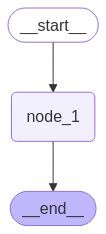

In [8]:
from operator import add
from typing import Annotated

class State(TypedDict):
    foo: Annotated[list[int], add]

def node_1(state):
    print("---Node 1---")
    return {"foo": [state['foo'][0] + 1]}

# Build graph
builder = StateGraph(State)
builder.add_node("node_1", node_1)

# Logic
builder.add_edge(START, "node_1")
builder.add_edge("node_1", END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [12]:
graph.invoke({"foo" : [1]})

---Node 1---


{'foo': [1, 2]}

In [14]:
try:
    graph.invoke({"foo" : None})
except TypeError as e:
    print(f"TypeError occurred: {e}")

TypeError occurred: can only concatenate list (not "NoneType") to list


________________________________________________

## Пользовательские редукторы (Custom Reducers)

Чтобы решать подобные случаи, [мы также можем определить пользовательские редукторы](https://langchain-ai.github.io/langgraph/how-tos/subgraph/#custom-reducer-functions-to-manage-state).

Например, давайте определим пользовательскую логику редуктора для объединения списков и обработки случаев, когда один или оба входных значения могут быть `None`.

In [16]:
def reduce_list(left: list | None, right: list | None) -> list:
    """Safely combine two lists, handling cases where either or both inputs might be None.

    Args:
        left (list | None): The first list to combine, or None.
        right (list | None): The second list to combine, or None.

    Returns:
        list: A new list containing all elements from both input lists.
               If an input is None, it's treated as an empty list.
    """
    if not left:
        left = []
    if not right:
        right = []
    return left + right

class DefaultState(TypedDict):
    foo: Annotated[list[int], add]

class CustomReducerState(TypedDict):
    foo: Annotated[list[int], reduce_list]

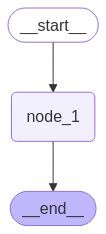

In [18]:
def node_1(state):
    print("---Node 1---")
    return {"foo": [2]}

# Build graph
builder = StateGraph(DefaultState)
builder.add_node("node_1", node_1)

# Logic
builder.add_edge(START, "node_1")
builder.add_edge("node_1", END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [19]:
try:
    print(graph.invoke({"foo" : None}))
except TypeError as e:
    print(f"TypeError occurred: {e}")

TypeError occurred: can only concatenate list (not "NoneType") to list


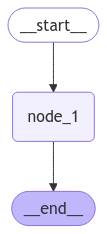

In [20]:
# Build graph
builder = StateGraph(CustomReducerState)
builder.add_node("node_1", node_1)

# Logic
builder.add_edge(START, "node_1")
builder.add_edge("node_1", END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [21]:
try:
    print(graph.invoke({"foo" : None}))
except TypeError as e:
    print(f"TypeError occurred: {e}")

---Node 1---
{'foo': [2]}
